<h1 style="font-size: 36px; color: blue;">STOWA Proevenverzameling tool v5.0</h1>

Deze Jupyter notebook bevat functies opgenomen in de python package PV-tooling ### voor het opstellen van lokale of regionale proevenverzamelingen voor het bepalen van geotechnische parameters. De methode is ontwikkeld voor het uitvoeren van analyses in relatie tot de geotechnische stabiliteit van dijken, maar kan ook breder worden toegepast. De notebook dient tevens als handleiding om de gebruiker stapsgewijs te ondersteunen bij het opstellen van een proevenverzameling.

Met de beschikbare functies kunnen zowel gedraineerde als ongedraineerde sterkteparameters worden berekend alsmede enkele samendrukkingsparameters. Van deze parameters worden verwachtingswaarde, karakteristieke waarde en rekenwaarde bepaald. 

De functies zijn opgesteld conform de werkwijze beschreven in [Statistische methoden t.b.v. proevenverzamelingen, DIV, v1.0], zie tevens: https://publicwiki.deltares.nl/spaces/HWBPMacro/pages/217120830/Sterkte+van+grond#Sterktevangrond-150.
De tool bevat tevens hulpmiddelen voor het onderscheiden of samenvoegen van groepen in een verzameling op basis van verschillende kenmerken. 

De onderliggende data om een proevenverzameling samen te stellen is beschreven in een vaste structuur. Deze structuur is vastgelegd in een uitwisselformat. Het uitwisselformat-database-proevenverzameling_versie_4_2x.xlsx. De geotechnische laboratoria kennen deze database en kunnen deze database vullen met resultaten van grond- en laboratoriumonderzoek. Op deze wijze ontstaat er uniformering op het gebied van data-uitwisseling en –opslag van proefresultaten.

NB. De verantwoordelijkheid voor het gebruik van deze tools ligt bij de gebruiker.

In [6]:
# Importeren van benodigde packages

import importlib.util

# Functie om te controleren of een package is geïnstalleerd
def check_package_install(package_name):
    package_spec = importlib.util.find_spec(package_name)
    if package_spec is None:
        print(f"{package_name} is niet geïnstalleerd. Installatie wordt gestart...")
        !pip install {package_name}
    else:
        print(f"{package_name} is al geïnstalleerd.")

# Controleer en installeer indien nodig
check_package_install("openpyxl")
check_package_install("ipyfilechooser")
check_package_install("pandas_schema")
check_package_install("xlsxwriter")
check_package_install("ipywidgets")


#!pip uninstall C:\python_cursus\PVtool2025_github\dist\pv_tool-0.1.0-py3-none-any.whl
#!pip install --force-reinstall C:\python_cursus\PVtool2025_github\dist\pv_tool-0.1.3-py3-none-any.whl

!pip install C:\python_cursus\PVtool2025_github\dist\pv_tool-0.1.3-py3-none-any.whl

openpyxl is al geïnstalleerd.
ipyfilechooser is al geïnstalleerd.
pandas_schema is al geïnstalleerd.
xlsxwriter is al geïnstalleerd.
ipywidgets is al geïnstalleerd.
Defaulting to user installation because normal site-packages is not writeable
Processing c:\python_cursus\pvtool2025_github\dist\pv_tool-0.1.3-py3-none-any.whl
  Using cached pandas-2.3.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.3.2-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.16.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached plotly-6.2.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached gitpython-3.1.45-py3-none-any.whl.metadata (13 kB)
  Using cached pandas_schema-0.3.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached xlsxwriter-3.2.5-py3-none-any.whl.metadata (2.7 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadat

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
Processing c:\python_cursus\pvtool2025_github\dist\pv_tool-0.1.3-py3-none-any.whl
pv-tool is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


## Stap 1: Inladen van benodigde data

De benodigde data voor het bepalen van geotechnische parameters kan op 3 manieren worden ingeladen in deze notebook.
- Op basis van de data in de excel versie van de proevenverzamelingtool (vanaf versie 4.2n of hoger) waarin zowel reeds proevenverzamelingen zijn onderscheiden als geotechnische parameters zijn vastgesteld. NB. de onderscheiden verzamelingen worden als uitgangspunt worden ingeladen, de sterkteparameters worden opnieuw berekend. Onderliggende keuzes zoals het gewenste rekpercentage en de gekozen raaklijnen worden niet ingelezen uit de Excelversie. 
- Op basis van het Excel Uitwisselformat-database-proevenverzameling_versie_4_2x.xlsx waarin nog geen verzamelingen onderscheiden zijn.

Zie tevens: https://github.com/kkpdata/Proevenverzamelingentool/

De proevenverzamelingtool of het uitwisselformat worden omgezet naar het template proevenverzamelingtool 5.0 

- Op basis van het Excel template voor de Proevenverzameling 5.0. Deze bestaat uit de data conform het uitwisselformat 4.2 aangevuld met de benodigde in en uitvoerdata van voorliggende tooling.

In [7]:
# Laden van widgets voor uploaden bestanden
import ipywidgets as widgets
from IPython.display import display, Markdown
from ipyfilechooser import FileChooser


# Dropdown widget voor keuze template
dropdown_template = widgets.Dropdown(
    options=[
        'Proevenverzamelingtool 4.2n of hoger', 
        'STOWA uitwisselingsformat 4.2x', 
        'Proevenverzamelingtool 5.0'
    ],  # De opties in het menu
    value='Proevenverzamelingtool 5.0',  # Standaard geselecteerde waarde
    description='Template:',
    disabled=False, 
    layout=widgets.Layout(width='400px') 
)


# filter_pattern="*.xlsm",  # Filter voor alleen .xlsm bestanden


# Maak een FileChooser-widget
file_chooser_import = FileChooser(
    '/',
    title="Selecteer een bestand om te uploaden",
    show_hidden=False  # Verberg verborgen bestanden
)

#Titel
display(Markdown("**Stap 1: Kies Excel template voor uploaden data:**"))

# Toon de dropdown widget keuze template
display(dropdown_template)

# Toon widget voor keuze uploaden bestand
display(file_chooser_import)

print()

**Stap 1: Kies Excel template voor uploaden data:**

Dropdown(description='Template:', index=2, layout=Layout(width='400px'), options=('Proevenverzamelingtool 4.2n…

FileChooser(path='C:\', filename='', title='Selecteer een bestand om te uploaden', show_hidden=False, select_d…

## Stap 2: Importeren en valideren data

De validatie bestaat uit de volgende controles: voor de verschillende typen proeven – classificatie, CRS-proef, samendrukkingsproef, DSS-proef en triaxiaalproef – wordt per regel gecontroleerd of er een proef is uitgevoerd (data ingevuld) en zo ja, of de velden die in de PV-tool benodigd zijn volledig en correct zijn ingevuld.

Het resultaat van de validatie wordt opgeslagen in een Excel-bestand, waarin per gevalideerde kolom en regel het resultaat wordt weergegeven. Daarnaast wordt per kolom aangegeven hoeveel fouten zijn aangetroffen. Ook wordt vermeld of een bepaalde kolom noodzakelijk is voor de functionaliteit van de tooling of dat de tooling ook zonder die kolom kan worden uitgevoerd.

In [172]:
from pv_tool.imports.import_data import Dbase
from pathlib import Path
dbase = Dbase()

# Controleer dropdown template en geef de gekozen waarde terug
if dropdown_template.value:
    print(f'Je hebt gekozen: {dropdown_template.value}')
else:
    print("Er is geen template geselecteerd.")

# bepaal source voor template
template_mapping = {
    "Proevenverzamelingtool 4.2n of hoger" : "PV-tool",
    "STOWA uitwisselingsformat 4.2x" : "Stowa",
    "Proevenverzamelingtool 5.0" : "Dbase"
}
template_code = template_mapping.get(dropdown_template.value, "Onbekend template")
print(f"Code in script: {template_code}")

# Controleer of een bestand is geselecteerd
if file_chooser_import.selected:
    # Verkrijg het volledige pad van het geselecteerde bestand
    full_path = file_chooser_import.selected
    # Verkrijg de directory en bestandsnaam
    selected_directory = file_chooser_import.selected_path
    filename = file_chooser_import.selected_filename

    # Print de resultaten
    print(f"Geselecteerd bestand: {filename}")
    print(f"Geselecteerde directory: {selected_directory}")
    print(f"Volledig pad: {full_path}")
else:
    print("Er is geen bestand geselecteerd. Selecteer een bestand voordat je verder gaat.")

#C:\python_cursus\PVtool2025_github\import\SAFE_PVTOOL.xlsm

#import dir en bestandsnaam en export directory
dir_in = (file_chooser_import.selected)
dir2 = Path(file_chooser_import.selected_path)

#starten importeren en valideren
#dbase.import_data_and_validate(source='PV-tool', source_dir=dir_in, export_path=dir2)
dbase.import_data_and_validate(source = template_code, source_dir=dir_in, export_path=dir2)

#export template
dbase.export_dbase_to_excel(export_dir=dir2)

Je hebt gekozen: Proevenverzamelingtool 4.2n of hoger
Code in script: PV-tool
Geselecteerd bestand: SAFE_PVTOOL.xlsm
Geselecteerde directory: C:\python_cursus\PVtool2025_github\import
Volledig pad: C:\python_cursus\PVtool2025_github\import\SAFE_PVTOOL.xlsm
Excel-bestand geëxporteerd naar: C:\python_cursus\PVtool2025_github\import\Dbase-template.xlsx


## Stap 4a: Bepalen gedraineerde parameters triaxiaalproeven op basis van fit (C en Phi)

In deze stap worden op basis van de data vastgelegd in het template PV-tool 5.0. gedraineerde parameters bepaald. Maak  een keuze uit de verzameling waarop de statistische analyse moet plaatsvinden. Als er nog geen aparte verzamelingen onderscheiden zijn in het veld (PV_NAAM) worden alle triaxaalproeven in één verzameling opgenomen. 

Als gebruiker kunnen handmatig verzamelingen worden opgegeven in de Excel template in het veld PV_NAAM of er kan gebruik worden gemaakt van de functie:
Definiëren en aanpassen van verzamelingen (stap #). Met behulp van de functie ## kunnen in de grafiek met behulp van de selectietool (should have) ook één of meer proefresultaten worden geselecteerd en worden toegekend aan een andere groep.

Geef  het te hanteren rekpercentage op waarbij de s' en t zijn bepaald: 2%, 5%, 15%, eindrek of bij pieksterkte. 
Indien er eerder parameters zijn vastgesteld worden de gemaakte keuzes voor het % en de raaklijnen ingeladen.

Ook kunnen meerdere verzamelingen getoond worden.

In [173]:
# Laden van widgets voor keuzes afleiden gedraineerde parameters
import ipywidgets as widgets
from IPython.display import display, Markdown

dbase_df = dbase.dbase_df

#### Inlezen lijst met unieke namen in PV_NAAM

# Filter het dataframe waar ALG__TRIAXIAAL True is
filtered_df = dbase_df[dbase_df['ALG__TRIAXIAAL'] == True]
# Selecteer de kolom PV_NAAM en haal unieke waarden op
unique_names = filtered_df['PV_NAAM'].unique()
# Converteer naar een lijst
unique_names_list = unique_names.tolist()


#### Widgets definieren 

# Dropdown widget voor rek%
dropdown_rekpercentage = widgets.Dropdown(
    options=[
        '2% rek', 
        '5% rek',
        '15% rek',
        'eindsterkte',
        'pieksterkte',
    ],  # De opties in het menu
    value='eindsterkte',  # Standaard geselecteerde waarde
    disabled=False, 
    layout=widgets.Layout(width='400px')  # Stel de breedte van de widget in
)

import ipywidgets as widgets

# Dropdown widget met unieke namen uit het dataframe
dropdown_verzameling_txt = widgets.Dropdown(
    options=unique_names_list,  # Gebruik de lijst met unieke namen als opties
    value=unique_names_list[0] if unique_names_list else None,  # Standaard geselecteerde waarde
    disabled=False, 
    layout=widgets.Layout(width='400px')  # Stel de breedte van de widget in
)

#### WIDGETS TONEN

# Toon de dropdown widget verzameling
display(Markdown("**Kies verzameling voor statistische analyse:**"))
display(dropdown_verzameling_txt)

# Titel keuze proevenverzameling vergelijken
#display(Markdown("**Kies verzameling ter vergelijking:**"))
print()
# hoe / wat kunnen we doen om keuze voor meerdere verzamelingen op te nemen?

# Toon de dropdown widget rekpercentage
display(Markdown("**Kies rekpercentage s'en t:**"))
display(dropdown_rekpercentage)

print()

**Kies verzameling voor statistische analyse:**

Dropdown(layout=Layout(width='400px'), options=('TXT_testset_klei', 'TXT_WAM_outlier', 'TXT_WAM_klei_zwaar_tra…

**Kies rekpercentage s'en t:**

Dropdown(index=3, layout=Layout(width='400px'), options=('2% rek', '5% rek', '15% rek', 'eindsterkte', 'piekst…

In [169]:
# colums=['TXT_SS_S\'_BIJ_T_EIND', 'TXT_SS_T_EIND']
#print(dbase_df)
test = dbase_df['TXT_SS_T_EIND'].unique()
print(test)

[  nan 47.34 46.05 43.57 18.14 46.63 18.49 30.04 18.64 32.06 50.02 36.88
 22.28 22.05 28.19 24.26 64.87 38.   33.29 47.25 68.75 67.1 ]


In [174]:
import ipywidgets as widgets
import math
from IPython.display import display, Markdown
from pv_tool.analysis.c_phi_analysis import CPhiAnalyse
from pv_tool.analysis.variables import *

dbase_df = dbase.dbase_df
#print(dbase_df.index)

#voor C-phi analyse uit met gekozen verzameling en rekpercentage en berekenen benaderingen.
analyse = CPhiAnalyse(dbase=dbase, investigation_groups=[dropdown_verzameling_txt.value], effective_stress= dropdown_rekpercentage.value,
                      analysis_type='TXT_CPhi')
analyse._run()


# Lees benaderingswaarden in voor afleiden gemiddelde en karakteristieke waarden
PV_A2_PHI_GEM_benadering = round(0.5, 2) # dummy waarde
PV_A1_COH_GEM_benadering = round(analyse.cohesie_gem_handmatig, 2)
PV_A2_PHI_KAR_benadering = round(analyse.phi_kar_handmatig, 2)
PV_A1_COH_KAR_benadering = round(analyse.cohesie_kar_handmatig, 2)


### Deze parameters moeten worden ingelezen uit de resultaten tabel als deze is ingevuld, anders benadering gebruiken.
PV_A1_COH_GEM_handmatig = PV_A1_COH_GEM_benadering
PV_A2_PHI_KAR_handmatig = PV_A2_PHI_KAR_benadering
PV_A1_COH_KAR_handmatig = PV_A1_COH_KAR_benadering
PV_PARTPHI = 1
PV_PARTCOH = 1
PV_TYPEVERZAMELING = 0.75

# Maak een raster van 8 rijen en 3 kolommen (7 data rijen + 1 header rij)
grid = widgets.GridspecLayout(8, 3)

# Vul de eerste rij met veldnamen
grid[0, 0] = widgets.Label('Beschrijving')
grid[0, 1] = widgets.Label('Benadering')
grid[0, 2] = widgets.Label('Invoer')

# Beschrijvingen voor de eerste kolom
descriptions = [
    'a2gem (phi gemiddeld)',
    'a1gem =snijpunt y-as (cohesie gemiddeld)',
    'a2kar (phi karakteristiek)',
    'a1kar =snijpunt y-as (cohesie karakteristiek)',
    'partiele materiaalfactor tan phi [-]',
    'partiele materiaalfactor cohesie [-]',
    'type verzameling: lokaal = 1,0; regionaal = 0,75',
]

# Benaderingen op basis van regressie
benadering_values = [
    PV_A2_PHI_GEM_benadering,
    PV_A1_COH_GEM_benadering,
    PV_A2_PHI_KAR_benadering,
    PV_A1_COH_KAR_benadering,
    '-',  # Geen benadering voor partiele materiaalfactor tan phi
    '-',  # Geen benadering voor partiele materiaalfactor cohesie
    '-',  # Geen benadering voor type verzameling
]

# Waarden voor de derde kolom
invoer_values = [
    None,  # Eerste rij is niet invulbaar
    PV_A1_COH_GEM_handmatig,  # Tweede rij
    PV_A2_PHI_KAR_handmatig,  # Derde rij
    PV_A1_COH_KAR_handmatig,  # Vierde rij
    PV_PARTPHI,  # Vijfde rij
    PV_PARTCOH,  # Zesde rij
    PV_TYPEVERZAMELING,  # Zevende rij
]

# Functie om wijzigingen in kolom 3 op te slaan
def on_value_change(change, row):
    global PV_A1_COH_GEM_handmatig, PV_A2_PHI_KAR_handmatig, PV_A1_COH_KAR_handmatig, PV_PARTPHI, PV_PARTCOH, PV_TYPEVERZAMELING
    new_value = change['new']
    if row == 1:  # Tweede rij
        PV_A1_COH_GEM_handmatig = new_value
    elif row == 2:  # Derde rij
        PV_A2_PHI_KAR_handmatig = new_value
    elif row == 3:  # Vierde rij
        PV_A1_COH_KAR_handmatig = new_value
    elif row == 4:  # Vijfde rij
        PV_PARTPHI = new_value
    elif row == 5:  # Zesde rij
        PV_PARTCOH = new_value
    elif row == 6:  # Zevende rij
        PV_TYPEVERZAMELING = new_value

# Vul de tabel
for i, (desc, benadering, invoer) in enumerate(zip(descriptions, benadering_values, invoer_values), start=0):
    grid[i+1, 0] = widgets.Label(desc)  # Beschrijving in de eerste kolom
    grid[i+1, 1] = widgets.Label(str(benadering))  # Waarde in de tweede kolom, met '-' indien geen benadering
    
    if i == 0:  # Eerste rij in de derde kolom is niet invulbaar
        grid[i+1, 2] = widgets.Label('-')
    else:
        input_widget = widgets.FloatText(value=invoer)  # Waarde in de derde kolom
        grid[i+1, 2] = input_widget
        input_widget.observe(lambda change, row=i: on_value_change(change, row), names='value')


# Toon de keuze verzameling en rekpercentage 
markdown_text = f"""
**Verzameling en rekpercentage: {dropdown_verzameling_txt.value}, s'- t bij: {dropdown_rekpercentage.value}****"""
display(Markdown(markdown_text))
        
# Toon de tabelwidget
display(Markdown("**Opgeven parameters effectieve schuifsterkteparameters (fit):**"))
display(grid)



**Verzameling en rekpercentage: TXT_testset_klei, s'- t bij: eindsterkte****

**Opgeven parameters effectieve schuifsterkteparameters (fit):**

GridspecLayout(children=(Label(value='Beschrijving', layout=Layout(grid_area='widget001')), Label(value='Benad…

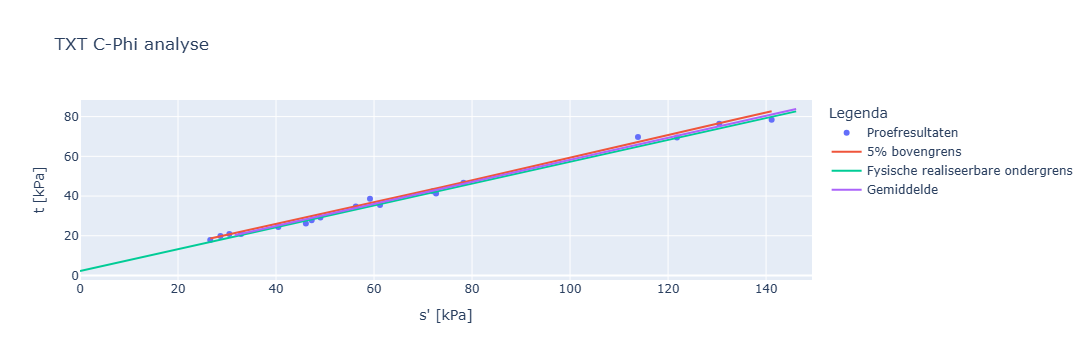

In [175]:

#voer C-phi analyse uit met invoer
analyse = CPhiAnalyse(dbase=dbase, investigation_groups=[dropdown_verzameling_txt.value], effective_stress= dropdown_rekpercentage.value,
                      analysis_type='TXT_CPhi')

analyse.apply_parameters(cohesie_gem = PV_A1_COH_GEM_handmatig)
analyse.apply_parameters(phi_kar = PV_A2_PHI_KAR_handmatig)
analyse.apply_parameters(cohesie_kar = PV_A1_COH_KAR_handmatig)

analyse.apply_settings(material_factor_cohesion = 1) 
analyse.apply_settings(material_factor_tan_phi = 1) 

#analyse.apply_settings(alpha = Alpha.LOCAL) 

#Voer 
analyse._run()

#analyse.factsheet()
analyse.show_figure()


In [101]:
# schrijf resultaten weg in export




In [102]:
#gewijzigde input voor fit.

print(f"PV_A1_COH_GEM_handmatig: {PV_A1_COH_GEM_handmatig}")
print(f"PV_A2_PHI_KAR_handmatig: {PV_A2_PHI_KAR_handmatig}")
print(f"PV_A1_COH_KAR_handmatig: {PV_A1_COH_KAR_handmatig}")
print(f"PV_PARTPHI: {PV_PARTPHI}")
print(f"PV_PARTCOH: {PV_PARTCOH}")
print(f"PV_TYPEVERZAMELING: {PV_TYPEVERZAMELING}")

PV_A1_COH_GEM_handmatig: 6.61
PV_A2_PHI_KAR_handmatig: 0.5
PV_A1_COH_KAR_handmatig: 6.06
PV_PARTPHI: 1
PV_PARTCOH: 1
PV_TYPEVERZAMELING: 0.75


In [103]:
# work in progress widget voor Shansep

import ipywidgets as widgets
from IPython.display import display

# Vooraf berekende waarden ingeven. Deze worden straks vanuit de berekening ingevoerd.

# Kolom 2: Snijpunt y-as
SNIJPUNT_GEM_BENADERING_R2 = 9.75
SNIJPUNT_GEM_BENADERING_R3 = None
SNIJPUNT_GEM_BENADERING_R4 = None
SNIJPUNT_GEM_BENADERING_R5 = None

# Kolom 3: Schuifsterkteratio S
S_GEM_BENADERING_UIT_S_en_POP_R2 = 0.324
S_GEM_BENADERING_UIT_S_en_m_R3 = 0.324
S_GEM_BENADERING_R4 = None
S_GEM_BENADERING_UIT_S_OCR1_R5 = 0.306

# Kolom 4: Sterktetoename exponent m
m__GEM_BENADERING_R2 = None
m_GEM_BENADERING_uit_S_en_m_R3 = 0.95
m_GEM_BENADERING_R4 = None
m_GEM_BENADERING_R5 = None

# Kolom 5: POP
POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1 = 32
POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R2 = POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1
POP_GEM_BENADERING_UIT_TXT_R3 = 44
POP_GEM_BENADERING_R4 = None

# Beschrijvingen (eerste kolom)
descriptions = [
    "bepaling S en POP uit triaxiaal- of DSS proeven",
    "bepaling S en m uit triaxiaal- of DSS proeven",
    "o.b.v. opgegeven POP bij triaxiaal- of DSS proeven",
    "bepaling S uit triaxiaal- of DSS proeven OCR=1"
]

# Maak een raster van 6 rijen en 5 kolommen
grid = widgets.GridspecLayout(6, 5, width='1050px')  # Breder raster

# Veldnamen (eerste rij)
grid[0, 0] = widgets.Label("Parameters", layout=widgets.Layout(width='300px'))  # Brede eerste kolom
grid[0, 1] = widgets.Label("Snijpunt y-as")
grid[0, 2] = widgets.Label("Schuifsterkteratio S")
grid[0, 3] = widgets.Label("Sterkte toename exponent m")
grid[0, 4] = widgets.Label("POP")

# Functie voor berekening van rij 6 kolom 5
def bereken_resultaat(change):
    try:
        kolom_2 = float(input_row_6_kol_2.value)
        kolom_3 = float(input_row_6_kol_3.value)
        kolom_4 = float(input_row_6_kol_4.value)
        result.value = str(kolom_2 + kolom_3 + kolom_4)
    except ValueError:
        result.value = "Invalid"

# Vul de tabel rijen 2 t/m 5 met berekende waarden
for i, (desc, y_as, S, m, pop) in enumerate(zip(
    descriptions,
    [SNIJPUNT_GEM_BENADERING_R2, SNIJPUNT_GEM_BENADERING_R3, SNIJPUNT_GEM_BENADERING_R4, SNIJPUNT_GEM_BENADERING_R5],
    [S_GEM_BENADERING_UIT_S_en_POP_R2, S_GEM_BENADERING_UIT_S_en_m_R3, S_GEM_BENADERING_R4, S_GEM_BENADERING_UIT_S_OCR1_R5],
    [m__GEM_BENADERING_R2, m_GEM_BENADERING_uit_S_en_m_R3, m_GEM_BENADERING_R4, m_GEM_BENADERING_R5],
    [POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R1, POP_GEM_BENADERING_UIT_snijpunt_S_en_m_R2, POP_GEM_BENADERING_UIT_TXT_R3, POP_GEM_BENADERING_R4]
), start=1):
    grid[i, 0] = widgets.Label(desc, layout=widgets.Layout(width='350px'))  # Beschrijving (eerste kolom)
    grid[i, 1] = widgets.Label(str(y_as) if y_as is not None else "-")  # Snijpunt y-as
    grid[i, 2] = widgets.Label(str(S) if S is not None else "-")  # Schuifsterkteratio S
    grid[i, 3] = widgets.Label(str(m) if m is not None else "-")  # Sterkte toename exponent m
    grid[i, 4] = widgets.Label(str(pop) if pop is not None else "-")  # POP

# Toevoegen van invoervelden in rij 6
grid[5, 0] = widgets.Label("Handmatige invoer", layout=widgets.Layout(width='350px'))
input_row_6_kol_2 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
input_row_6_kol_3 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
input_row_6_kol_4 = widgets.FloatText(value=0.0, layout=widgets.Layout(width='180px'))
result = widgets.Label("")

# Koppel invoervelden aan de tabel
grid[5, 1] = input_row_6_kol_2
grid[5, 2] = input_row_6_kol_3
grid[5, 3] = input_row_6_kol_4

# Bereken resultaat in kolom 5
input_row_6_kol_2.observe(bereken_resultaat, names="value")
input_row_6_kol_3.observe(bereken_resultaat, names="value")
input_row_6_kol_4.observe(bereken_resultaat, names="value")
grid[5, 4] = result

# Toon de tabelwidget
display(Markdown("**Opgeven gemiddelde waarden (fit):**"))
display(grid)

**Opgeven gemiddelde waarden (fit):**

GridspecLayout(children=(Label(value='Parameters', layout=Layout(grid_area='widget001', width='300px')), Label…

In [166]:
# test c phi analyse
from pv_tool.analysis.c_phi_analysis import CPhiAnalyse
from pv_tool.analysis.variables import *

dbase_df = dbase.dbase_df
#print(dbase_df.index)

# Controleer dropdown keuze verzameling
if dropdown_verzameling_txt.value:
    print(f'Je hebt gekozen: {dropdown_verzameling_txt.value}')
else:
    print("Er is geen verzameling geselecteerd.")

# Controleer dropdown templates en geef de gekozen waarde terug
if dropdown_rekpercentage.value:
    print(f'Je hebt gekozen: {dropdown_rekpercentage.value}')
else:
    print("Er is geen template geselecteerd.")


analyse = CPhiAnalyse(dbase=dbase, investigation_groups=['TXT_SAFE_klei_licht_16_175'], effective_stress='eindsterkte',
#                      analysis_type='TXT_CPhi')
#analyse = CPhiAnalyse(dbase=dbase, investigation_groups=[dropdown_verzameling_txt.value], effective_stress= dropdown_rekpercentage.value,
                      analysis_type='TXT_CPhi')


#analyse.apply_parameters(cohesie_gem = 8)
#analyse.apply_parameters(phi_kar = 0.53)
#analyse.apply_parameters(cohesie_kar = 6.72)

#analyse.apply_settings(material_factor_cohesion = 1) 
#analyse.apply_settings(material_factor_tan_phi = 1) 

#analyse.apply_settings(alpha = Alpha.LOCAL) 

#analyse.factsheet()
analyse.show_figure()

# Bestandspad samenstellen: gekozen map + bestandsnaam
bestand_naam = f"{selected_directory}/c_phi_data_geforceerd.xlsx"
# Dataframe tussenstappen
df = analyse.cphi_analyses_data_df

# Exporteer DataFrame naar Excel
df.to_excel(bestand_naam, index=False)

Je hebt gekozen: TXT_SAFE_klei_zwaar
Je hebt gekozen: eindsterkte


AttributeError: 'float' object has no attribute 'shape'